# 1. Imports and Configuration
Importing necessary libraries (TensorFlow/Keras, NumPy, Matplotlib) and setting random seeds for reproducibility.

In [3]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


# 2. Dataset Generation
Generating synthetic data.
Rationale: A 50x50 grid has 2,500 possible positions. Generating 4,000 samples ensures >1x statistical coverage of the entire search space while maintaining a lightweight dataset.

In [4]:
def generate_dataset(num_samples=4000, img_size=50):
    """
    Generates synthetic grayscale images with 1 white pixel.

    Args:
        num_samples (int): Number of images to generate.
        img_size (int): Height/Width of the image.

    Returns:
        X: Image data normalized to [0, 1]
        y: Coordinate labels normalized to [0, 1]
    """
    # Initialize arrays
    X = np.zeros((num_samples, img_size, img_size, 1), dtype='float32')
    y = np.zeros((num_samples, 2), dtype='float32')

    for i in range(num_samples):
        # Randomly select coordinates
        x_coord = np.random.randint(0, img_size)
        y_coord = np.random.randint(0, img_size)

        # Set pixel value to 1.0 (Normalized 255)
        X[i, y_coord, x_coord, 0] = 1.0

        # Normalize coordinates to [0, 1] for stable training
        # We divide by img_size - 1 to map index 0->0.0 and 49->1.0
        y[i] = [x_coord / (img_size - 1), y_coord / (img_size - 1)]

    return X, y

# Configuration
IMG_SIZE = 50
NUM_SAMPLES = 4000
BATCH_SIZE = 32

# Generate Data
X, y = generate_dataset(NUM_SAMPLES, IMG_SIZE)

# Split Data (80% Train, 20% Test)
split_idx = int(NUM_SAMPLES * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (3200, 50, 50, 1)
Testing Data: (800, 50, 50, 1)


# 3. Model Architecture
Building a lightweight Convolutional Neural Network (CNN).
Rationale: We use `Flatten` rather than Global Pooling to preserve spatial information required for localization. The output uses a `Sigmoid` activation to strictly bound predictions between 0 and 1.

In [5]:
def build_model():
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

        # Conv Block 1: Capture low-level features
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2: Capture spatial hierarchy
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3: Deep features
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Flatten(),

        # Dense Layers for Coordinate Regression
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1), # Slight regularization

        # Output Layer: 2 units (x, y)
        # Sigmoid ensures output is always within valid image bounds [0, 1]
        layers.Dense(2, activation='sigmoid')
    ])

    # We use MSE for loss as it heavily penalizes outliers
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,762 (2.46 MB)

 Trainable params: 645,762 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Training
Training the model with Early Stopping to prevent overfitting and ensure optimal training time.

In [6]:
# Stop training if validation loss doesn't improve for 5 epochs
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20, # Usually converges in <10 epochs
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - loss: 0.0278 - mae: 0.1176 - val_loss: 0.0012 - val_mae: 0.0248
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 0.0014 - mae: 0.0276 - val_loss: 4.2733e-04 - val_mae: 0.0157
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 7.2435e-04 - mae: 0.0203 - val_loss: 2.8314e-04 - val_mae: 0.0122
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 5.8696e-04 - mae: 0.0186 - val_loss: 2.6945e-04 - val_mae: 0.0126
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - loss: 5.6217e-04 - mae: 0.0181 - val_loss: 1.8027e-04 - val_mae: 0.0102
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - loss: 5.2487e-04 - mae: 0.0174 - val_loss: 1.6099e-04 - val_mae: 0.0097
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 4.4383e-04 - mae: 0.0161 - val_loss: 2.2121e-04 - val_mae: 0.0120
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - loss: 4.8741e-04 - mae: 0.0170 - val_loss: 1.3255e-0

# 5. Performance Evaluation
Converting normalized predictions back to pixel coordinates and calculating Euclidean Distance error.

In [7]:
# Predict on Test Set
preds_norm = model.predict(X_test)

# Denormalize predictions and ground truth to pixel values
preds_pixel = preds_norm * (IMG_SIZE - 1)
y_true_pixel = y_test * (IMG_SIZE - 1)

# Calculate Euclidean Distance (Error in pixels)
# Distance = sqrt((x1-x2)^2 + (y1-y2)^2)
errors = np.sqrt(np.sum((preds_pixel - y_true_pixel)**2, axis=1))

# Metrics
mean_error = np.mean(errors)
max_error = np.max(errors)
accuracy_sub_1px = np.mean(errors < 1.0) * 100

print("-" * 30)
print(f"EVALUATION REPORT")
print("-" * 30)
print(f"Mean Euclidean Error: {mean_error:.4f} pixels")
print(f"Max Euclidean Error:  {max_error:.4f} pixels")
print(f"Accuracy (< 1 px):    {accuracy_sub_1px:.2f}%")
print("-" * 30)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
------------------------------
EVALUATION REPORT
------------------------------
Mean Euclidean Error: 0.5262 pixels
Max Euclidean Error:  2.0909 pixels
Accuracy (< 1 px):    91.25%
------------------------------


# 6. Visualization
Visualizing training loss and prediction examples to qualitatively assess model performance.

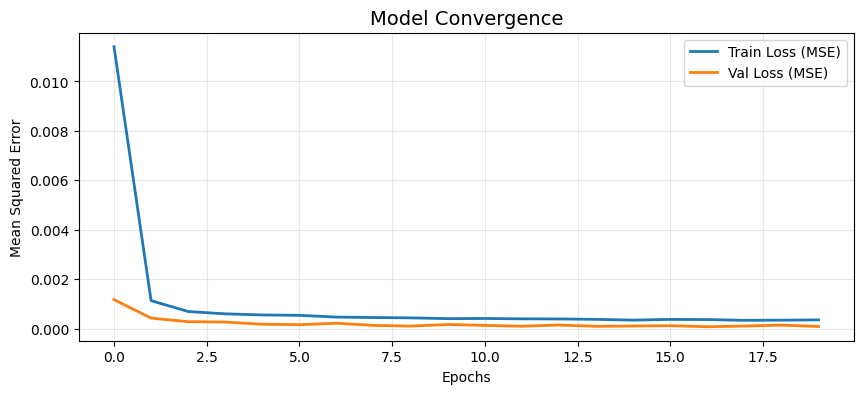

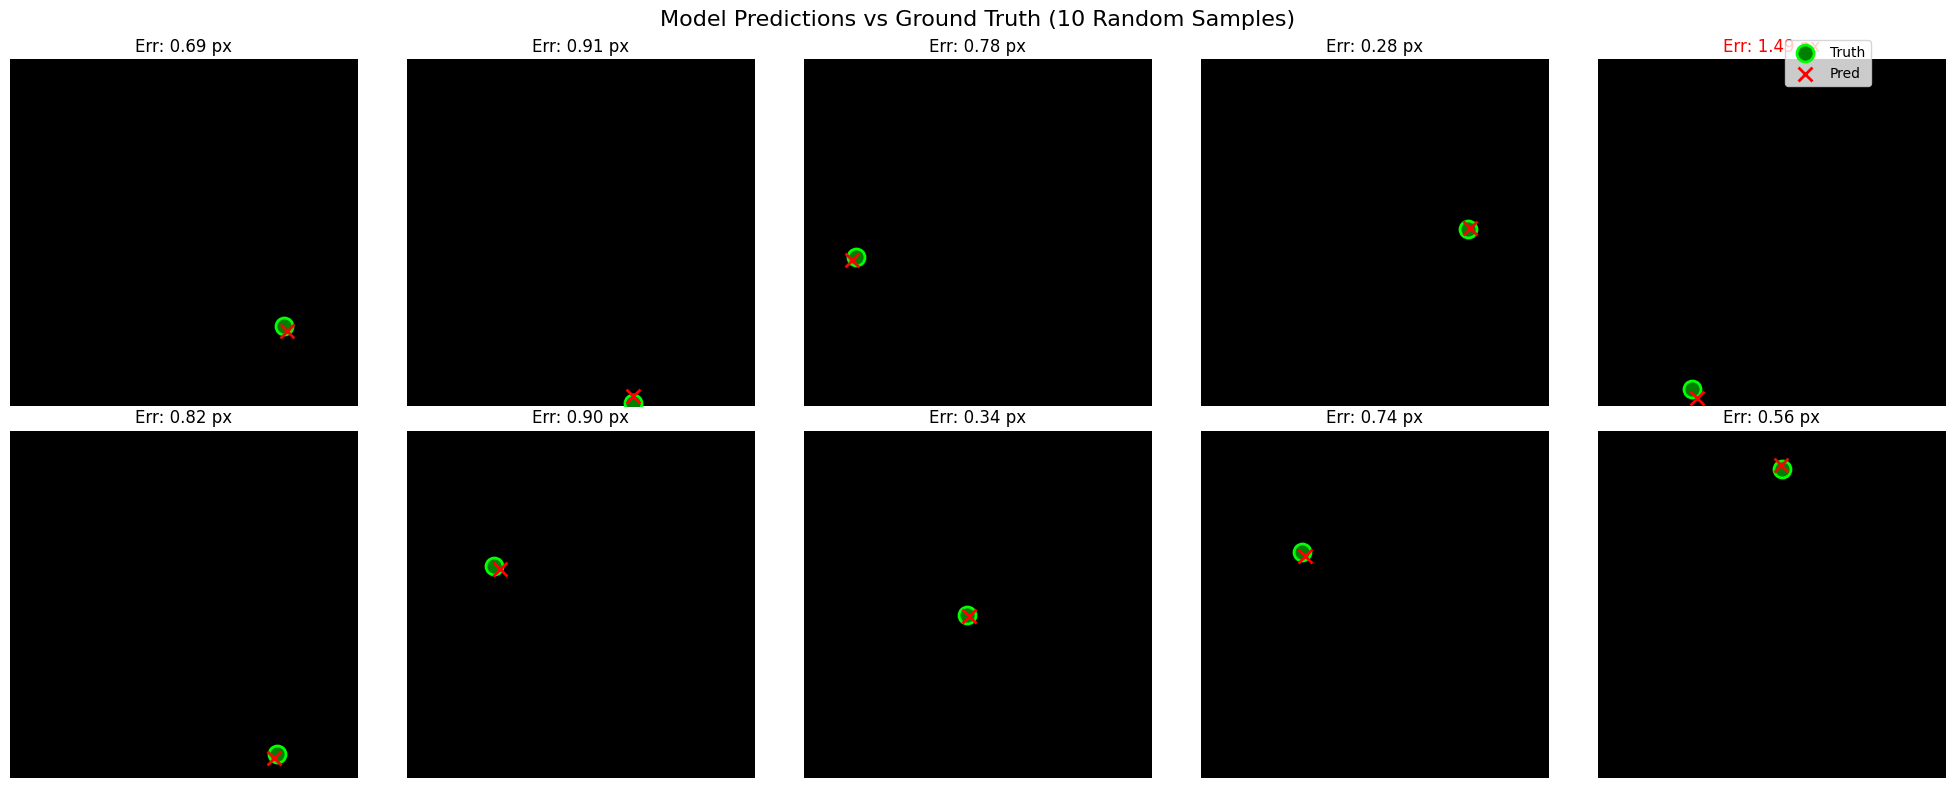

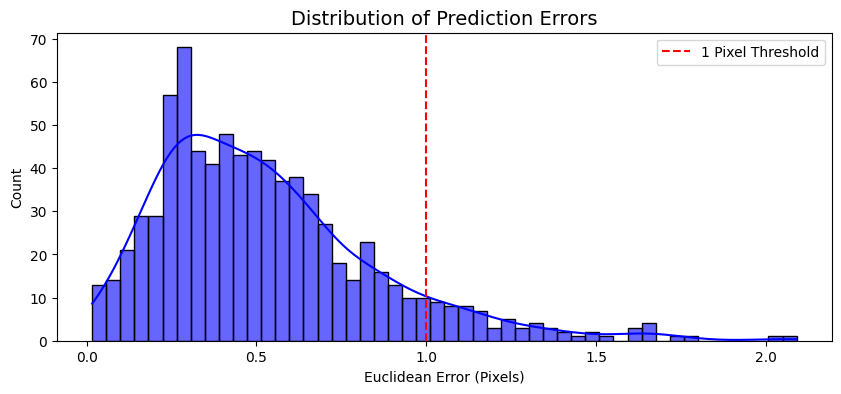

In [10]:
# ==========================================
# 6. ENHANCED VISUALIZATION
# ==========================================

# A. Plot Training History
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss (MSE)', linewidth=2)
plt.title('Model Convergence', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# B. Visual Prediction Grid (10 Samples)
num_samples_to_show = 10
indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'Model Predictions vs Ground Truth ({num_samples_to_show} Random Samples)', fontsize=16)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)

    # Coordinates
    true_x, true_y = y_true_pixel[idx]
    pred_x, pred_y = preds_pixel[idx]
    error_val = errors[idx]

    # Display Image
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)

    # Plot Truth (Green Circle)
    ax.scatter([true_x], [true_y], c='green', s=150, marker='o',
               facecolors='none', edgecolors='#00FF00', linewidth=2, label='Truth')

    # Plot Pred (Red Cross)
    ax.scatter([pred_x], [pred_y], c='red', s=100, marker='x',
               linewidth=2, label='Pred')

    # Styling
    ax.set_title(f"Err: {error_val:.2f} px", color='black' if error_val < 1.0 else 'red')
    ax.axis('off')

# Add a single legend for the whole figure
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.tight_layout()
plt.show()

# C. Error Distribution (Histogram)
plt.figure(figsize=(10, 4))
sns.histplot(errors, bins=50, kde=True, color='blue', alpha=0.6)
plt.axvline(x=1.0, color='red', linestyle='--', label='1 Pixel Threshold')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Euclidean Error (Pixels)')
plt.ylabel('Count')
plt.legend()
plt.show()